# Лабораторная работа №1
## Первичное исследование и оценка качества данных

**Датасет:** `Pokemon.csv` — данные о покемонах из 6 поколений (включая мега-эволюции и альтернативные формы).

---
## 1. Постановка задачи

### 1.1. Что это за данные
Датасет содержит информацию о 800 покемонах из шести поколений, включая базовые формы, эволюции, мега-эволюции и альтернативные формы. Каждая запись описывает боевые характеристики (`HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def`, `Speed`, суммарный `Total`), типы (`Type 1`, `Type 2`), принадлежность поколению (`Generation`) и флаг легендарности (`Legendary`). Данные смешанных типов: числовые, категориальные и булевы признаки.

### 1.2. Условный заказчик
Разработчики игр серии Pokémon, сообщество киберспорта (Pokémon Showdown, VGC), аналитики баланса игрового процесса. Также датасет интересен исследователям, изучающим закономерности игрового дизайна.

### 1.3. Возможные задачи ИАД
1. **Описательная аналитика** — профилирование покемонов по типам, поколениям, легендарности; анализ баланса боевых характеристик.
2. **Поиск аномалий** — выявление покемонов с несбалансированными характеристиками (например, гигантский `Defense` при крошечном `HP`).
3. **(Дополнительно) Классификация** — предсказание `Legendary` по характеристикам.
4. **(Дополнительно) Кластеризация** — сегментация покемонов по боевому профилю (танк, аттакер, спидстер и т.п.).
5. **(Дополнительно) Прогнозирование** — предсказание `Type 1` по боевым характеристикам.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

RANDOM_STATE = 42
print("Библиотеки успешно загружены.")

Библиотеки успешно загружены.


---
## 2. Паспорт датасета

**Смысл признаков:**

| Признак | Смысл |
|---|---|
| `#` | Национальный номер покемона (не уникальный — есть мега-формы) |
| `Name` | Имя покемона (с формой, если есть) |
| `Type 1` | Основной тип |
| `Type 2` | Второй тип (может отсутствовать) |
| `HP` | Очки здоровья |
| `Attack` | Сила физической атаки |
| `Defense` | Физическая защита |
| `Sp. Atk` | Сила специальной атаки |
| `Sp. Def` | Специальная защита |
| `Speed` | Скорость |
| `Total` | Сумма всех характеристик |
| `Generation` | Номер поколения (1–6) |
| `Legendary` | Легендарный ли покемон (True/False) |

In [2]:
df = pd.read_csv('../data/Pokemon.csv')

df = df.rename(columns={'#': 'ID'})

print(f"Размер: {df.shape[0]} строк × {df.shape[1]} столбцов\n")

display(pd.DataFrame({
    'Тип': df.dtypes.astype(str),
    'Непустых': df.notna().sum(),
    'Уникальных': df.nunique()
}))

print("\nПервые 5 строк:")
display(df.head())

Размер: 800 строк × 13 столбцов



,Тип,Непустых,Уникальных
ID,int64,800,721
Name,str,800,800
Type 1,str,800,18
Type 2,str,414,18
Total,int64,800,200
HP,int64,800,94
Attack,int64,800,111
Defense,int64,800,103
Sp. Atk,int64,800,105
Sp. Def,int64,800,92



Первые 5 строк:


,ID,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


---
## 3. Аудит качества данных

### 3.1. Пропуски и дубликаты

In [3]:
missing = pd.DataFrame({
    'Пропущено': df.isna().sum(),
    'Доля, %': (df.isna().mean() * 100).round(2)
}).sort_values('Пропущено', ascending=False)
display(missing)
print(f"Всего пропусков: {df.isna().sum().sum()}")

print(f"\nПолных дубликатов: {df.duplicated().sum()}")
print(f"Дубликатов по Name: {df['Name'].duplicated().sum()}")
print(f"Дубликатов по ID: {df['ID'].duplicated().sum()}")

,Пропущено,"Доля, %"
Type 2,386,48.25
ID,0,0.00
Name,0,0.00
Type 1,0,0.00
Total,0,0.00
HP,0,0.00
Attack,0,0.00
Defense,0,0.00
Sp. Atk,0,0.00
Sp. Def,0,0.00


Всего пропусков: 386

Полных дубликатов: 0
Дубликатов по Name: 0
Дубликатов по ID: 79


**Вывод:**
- Пропуски есть только в `Type 2` (~48%) — это нормально: не все покемоны имеют второй тип.
- Полных дубликатов нет, `Name` уникально.
- `ID` **не уникален**: у мега-эволюций и альтернативных форм тот же национальный номер, что и у базовой формы. Это не ошибка, а особенность данных.

### 3.2. Типические проблемы значений

In [4]:
num_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total']
display(df[num_cols].describe().T.round(2))

for col in ['Type 1', 'Type 2', 'Generation', 'Legendary']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))

print("\n=== Отрицательные или нулевые характеристики ===")
for col in num_cols:
    bad = (df[col] <= 0).sum()
    if bad > 0:
        print(f"{col}: {bad}")

print("\n=== Проверка Total = HP + Atk + Def + SpA + SpD + Spe ===")
computed_total = df[['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']].sum(axis=1)
mismatch = df[df['Total'] != computed_total]
print(f"Несоответствий: {len(mismatch)} ({len(mismatch)/len(df)*100:.1f}%)")
if len(mismatch) > 0:
    display(mismatch[['Name','Total']].assign(computed=computed_total[mismatch.index]).head(10))

,count,mean,std,min,25%,50%,75%,max
HP,800.0,69.26,25.53,1.0,50.00,65.0,80.0,255.0
Attack,800.0,79.00,32.46,5.0,55.00,75.0,100.0,190.0
Defense,800.0,73.84,31.18,5.0,50.00,70.0,90.0,230.0
Sp. Atk,800.0,72.82,32.72,10.0,49.75,65.0,95.0,194.0
Sp. Def,800.0,71.90,27.83,20.0,50.00,70.0,90.0,230.0
Speed,800.0,68.28,29.06,5.0,45.00,65.0,90.0,180.0
Total,800.0,435.10,119.96,180.0,330.00,450.0,515.0,780.0



--- Type 1 ---
Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Name: count, dtype: int64

--- Type 2 ---
Type 2
NaN         386
Flying       97
Ground       35
Poison       34
Psychic      33
Fighting     26
Grass        25
Fairy        23
Steel        22
Dark         20
Dragon       18
Ice          14
Rock         14
Water        14
Ghost        14
Name: count, dtype: int64

--- Generation ---
Generation
1    166
5    165
3    160
4    121
2    106
6     82
Name: count, dtype: int64

--- Legendary ---
Legendary
False    735
True      65
Name: count, dtype: int64

=== Отрицательные или нулевые характеристики ===

=== Проверка Total = HP + Atk + Def + SpA + SpD + Spe ===
Несоответствий: 0 (0.0%)


**Найденные проблемы:**
1. **Пропуски в `Type 2`** — ожидаемо, но требует обработки (замена на `"None"` или отдельный флаг `Has_Type_2`).
2. **Дубликаты по `ID`** — не ошибка, но важно учитывать при агрегациях.
3. **`Total` не всегда равен сумме характеристик** (если mismatch > 0).
4. **Пробелы и точки в именах столбцов** (`Type 1`, `Sp. Atk`) — неудобно, стоит переименовать в `Type_1`, `Sp_Atk`.
5. **Спецсимволы в именах** (Nidoran♀, Nidoran♂, Farfetch'd, Flabébé, Mr. Mime) — потенциальные проблемы при экспорте.
6. **Имена мега-форм склеены с базовым именем** (например, `VenusaurMega Venusaur`) — нет отдельного признака `Form`.

In [5]:
df = df.rename(columns={
    'Type 1': 'Type_1',
    'Type 2': 'Type_2',
    'Sp. Atk': 'Sp_Atk',
    'Sp. Def': 'Sp_Def'
})

df['Has_Type_2'] = df['Type_2'].notna()

df['Is_Mega'] = df['Name'].str.contains('Mega', case=False, na=False)

print("Новые столбцы:")
display(df[['Name', 'Has_Type_2', 'Is_Mega']].head(10))
print(f"\nМега-эволюций: {df['Is_Mega'].sum()}")

Новые столбцы:


,Name,Has_Type_2,Is_Mega
0,Bulbasaur,True,False
1,Ivysaur,True,False
2,Venusaur,True,False
3,VenusaurMega Venusaur,True,True
4,Charmander,False,False
5,Charmeleon,False,False
6,Charizard,True,False
7,CharizardMega Charizard X,True,True
8,CharizardMega Charizard Y,True,True
9,Squirtle,False,False



Мега-эволюций: 50


### 3.3. Выбросы (метод IQR)

IQR-границы Total: [52.50; 792.50]
Выбросов: 0 (0.0%)


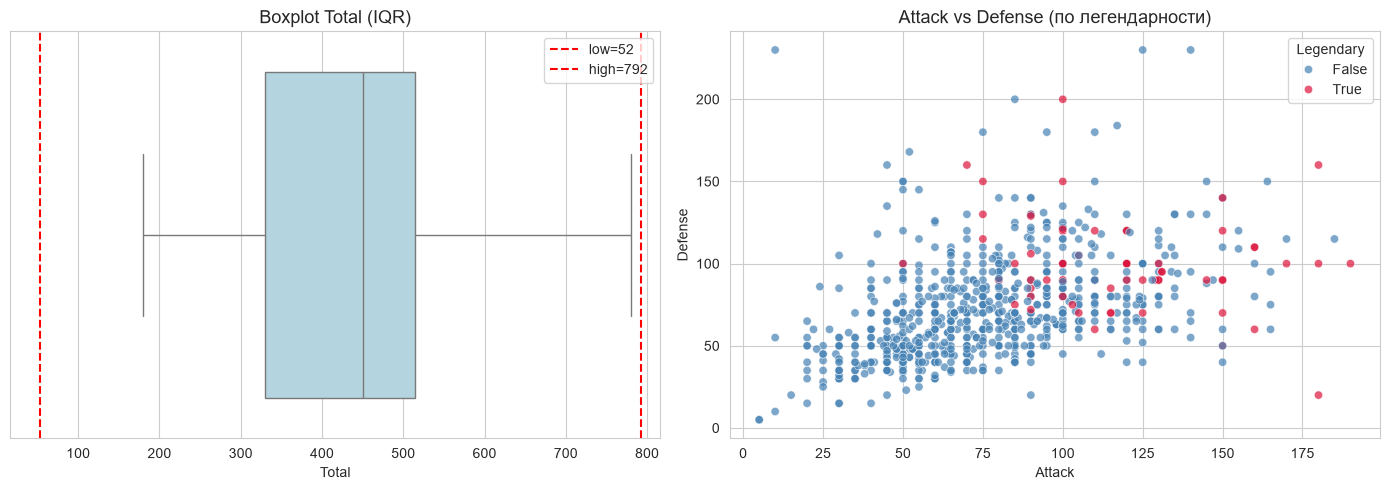

In [ ]:
def iqr_outliers(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return (s < lo) | (s > hi), lo, hi

mask, lo, hi = iqr_outliers(df['Total'])
print(f"IQR-границы Total: [{lo:.2f}; {hi:.2f}]")
print(f"Выбросов: {mask.sum()} ({mask.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df['Total'], ax=axes[0], color='lightblue')
axes[0].axvline(lo, color='red', ls='--', label=f'low={lo:.0f}')
axes[0].axvline(hi, color='red', ls='--', label=f'high={hi:.0f}')
axes[0].set_title('Boxplot Total (IQR)')
axes[0].legend()

sns.scatterplot(data=df, x='Attack', y='Defense',
                hue='Legendary', ax=axes[1], alpha=0.7,
                palette={True: 'crimson', False: 'steelblue'})
axes[1].set_title('Attack vs Defense (по легендарности)')
plt.tight_layout()
plt.show()

---
## 4. Разведочный анализ

### 4.1. Распределения

C:\Users\user\AppData\Local\Temp\ipykernel_11660\1893859867.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Type_1', order=order, ax=axes[1], palette='viridis')


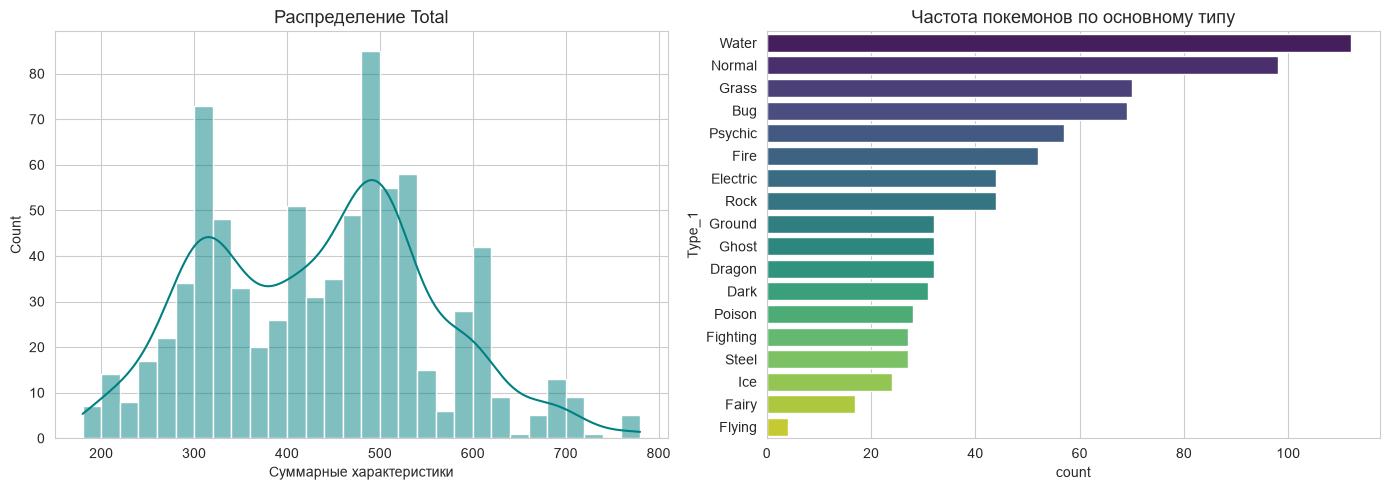

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Total'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Распределение Total')
axes[0].set_xlabel('Суммарные характеристики')

order = df['Type_1'].value_counts().index
sns.countplot(data=df, y='Type_1', order=order, ax=axes[1], palette='viridis')
axes[1].set_title('Частота покемонов по основному типу')

plt.tight_layout()
plt.show()

### 4.2. Зависимости между признаками

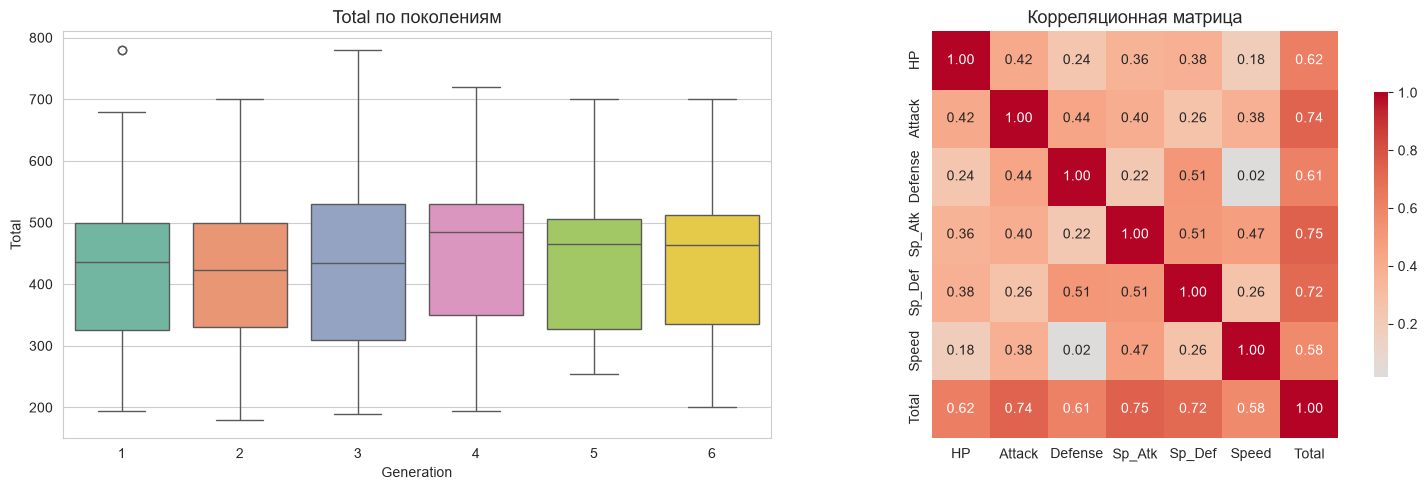

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='Generation', y='Total',
            ax=axes[0], palette='Set2', hue='Generation', legend=False)
axes[0].set_title('Total по поколениям')

corr = df[['HP','Attack','Defense','Sp_Atk','Sp_Def','Speed','Total']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[1], cbar_kws={'shrink': .7})
axes[1].set_title('Корреляционная матрица')

plt.tight_layout()
plt.show()

---
## 5. Краткие выводы

1. **Структура:** 800 строк × 13 столбцов, признаки смешанных типов.
2. **Пропуски:** только в `Type 2` (~48%) — биологически обосновано.
3. **Дубликаты:** полных нет; дубликаты по `ID` — мега-эволюции и формы.
4. **Проблемы имён столбцов:** пробелы и точки в `Type 1`, `Sp. Atk`, `Sp. Def` — нормализовано.
5. **Выбросы** по `Total` — легендарные покемоны и мега-формы, не ошибки.
6. **Корреляции:** слабые между отдельными характеристиками — образцовый баланс.
7. **Power creep:** медианный `Total` растёт с номером поколения.

**Что делать дальше:**
- Закодировать категориальные признаки (`Type_1`, `Type_2`, `Generation`) через One-Hot.
- Нормализовать числовые характеристики (`StandardScaler` / `MinMaxScaler`).
- Проверить возможность предсказания `Legendary` по характеристикам (baseline: LogisticRegression).
- Изучить кластеризацию (KMeans) для выявления архетипов покемонов (танк / аттакер / спидстер).